# $\Psi(2S)$ discovery with CMS data
#### Gabriele Radano, Matteo Bellino - Spring semester 2025

# 0. Importing packages

In [1]:
# Importing packages
import pickle as pkl                 # Needed to import the pkl files
import numpy  as np
import math                          # Needed to check if the bNLL is NaN (negative number inside the logarithm)
import matplotlib.pyplot as plt
import seaborn as sns
import lmfit                         # Package to minimize functions (it is more well-structured than scipy.optimize)
from dataclasses import dataclass
from scipy.integrate import quad     # Numerical integral evaluation, useful to compute the integral of the model inside the bin
import sys                           # Needed to know what's the highest float value accepted
from collections.abc import Iterable # Needed to check inside crystall_ball if we are giving an array or a float
import tensorflow as tf
import zfit
from zfit import z  # math backend of zfit
import zfit.z.numpy as znp
import os
import mplhep
os.environ["ZFIT_DISABLE_TF_WARNINGS"] = "1" #to disable warnings linked to zfit (they are not real errors, just warnings). Remove this line to see warnings

C:\Users\Gabriele\anaconda3\envs\env_Project\lib\site-packages\zfit\__init__.py:60: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


# 1. Loading data

In [2]:
mass_cut = 6.0

In [3]:
# Importing data from files
with open('DataSet.pkl', 'rb') as file: # The 'rb' stands for 'read binary', necessary for this kind of file
    data_HS = pkl.load(file)            # Data with High Statistics 
data_HS = data_HS[data_HS<mass_cut]

with open('DataSet_lowstat.pkl', 'rb') as file:
    data_LS = pkl.load(file)            # Data with Low Statistics
data_LS = data_LS[data_LS<mass_cut]

Bin number: 83


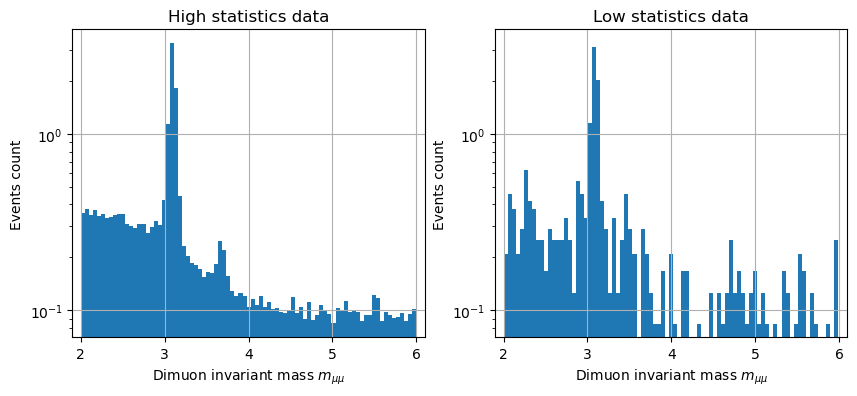

In [4]:
# Plotting raw data
normalize = True
scale     = 'log'
bin_num   = int(np.sqrt(len(data_HS))/2)
print(f'Bin number: {bin_num}')
fig, axes = plt.subplots(1,2, figsize=(10,4))

ax = axes[0]
ax.grid(1)
ax.hist(data_HS, density=normalize, bins=bin_num)
ax.set_title('High statistics data')
ax.set_xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
ax.set_ylabel('Events count')
ax.set_xlim((1.9,6.1))
ax.set_yscale(scale)
ylim = ax.set_ylim()

ax = axes[1]
ax.grid(1)
ax.hist(data_LS, density=normalize, bins=int(bin_num))
ax.set_title('Low statistics data')
ax.set_xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
ax.set_ylabel('Events count')
ax.set_xlim((1.9,6.1))
ax.set_ylim(ylim)
ax.set_yscale(scale)
plt.show()

# 2. Defining the model

## 2.1. Bare background

We want to use chebyshev polynomials to model the bare bkg, excluding the resonance of the J/$\Psi$ and the signal we are looking for of the $\Psi$(2S) we need to perform the following operations:
1. Make the polynomials positive:
   add 1 to each element of the polynomial
2. Normalize the polynomial in $[-1,1]$ (can be done analytically)
3. Take a linear combination and normalize the sum in $[-1,1]$ (one could simply normalize at the end)  

At this point one gets the following result:
\begin{equation}
    f(x) = \{a_3 \cdot \frac{(4x^3-3x +1)}{2} + a_2\cdot\frac{3x^2}{2} + a_1\cdot \frac{x+1}{2} + a_0\frac{1}{2}\} / {\sum a_i}
\end{equation}
However, we want to describe a pdf in the interval $[2,6]$, therefore we must perform a change of variable. Given z in $[2,6]$:
\begin{equation}
    x = -1 + 2 \frac{z-2}{6-2} \in [-1,1]
\end{equation}

**Watch out!**
Since probability/normalization must be conserved and we changed the measure, the pdf obtained applying the change of vairable must be divided by $dx/dz = 2$.

## 2.2. J/$\Psi$ and $\Psi(2S)$ resonances

We model the peak of the J/$\Psi$ resonance with a crystal ball distribution, which is conceived to describe the invariant mass distribution in the presence of energy losses (brehmstralung radiation). In our case, we are interested at a one-sided crystall ball, with the polynomial tail to the left (lower invariant masses due to energy loss). The distribution is a piecewise function, which turns to a polynomial at a certain point:
\begin{equation}
    f(x) = N\cdot\begin{cases}
    e^{-\frac{(x-\mu)^2}{2\sigma^2}} \qquad\qquad\qquad \frac{x-\mu}{\sigma}>-\alpha\\
    A\cdot(B-\frac{x-\mu}{\sigma})^{-n} \qquad \frac{x-\mu}{\sigma}<-\alpha
    \end{cases}
\end{equation}
The parameters $A, B$ are known, the factor N ensures proper normalization.

## 2.3. Combined model

Combining the three features we observe in the invariant mass spectrum may result in a big mess if not handled properly. Here we describe how we intend to tackle the problem. First, a rescaled-pdf will be defined *combined_model*: it will be obtained as

$$combined\_model(x) = \text{N}_\text{bkg}\cdot cheb3r(x) + \text{N}_\text{JPsi}\cdot crystal\_ball(x) + \text{N}_\text{Psi2S}\cdot crystal\_ball(x)$$

where each pdf is multiplied by the corresponding yield (the number of events expected for bkg, JPsi and Psi2S). Since each constituting pdf is normalized, the integral of this combined model is the total number of expected events. Keep in mind that the yield of the Psi2S resonance is expressed in terms of the cross section of the process as follows

$$\text{N}_{Psi2S} = 0.75 \cdot 37 \cdot \text{cross\_section}$$

where the efficiency (0.75) and the luminosity (37 inverse pb) are fixed and the cross section is expressed in pb. The other yields are simple optimization parameters.

This function is ready to be integrated inside each bin to provide the number of events the model predicts inside that bin. This integration will be performed by another function that will simply integrate combined_model inside the bins.

In [5]:
#Parameters and observables
obs = zfit.Space('mass', limits=(2.0, mass_cut))  # GeV
eps_uu = 0.75
lumi = 37

# Background parameters
a1 = zfit.Parameter("a1", -0.7, -2, 2)
a2 = zfit.Parameter("a2", 0.3, -2, 2)
a3 = zfit.Parameter("a3", -0.03, -2, 2)
yield_bkg = zfit.Parameter("yield_bkg", 18000, 0, 50000)

bkg = zfit.pdf.Chebyshev(obs=obs, coeffs=[a1, a2, a3])
bkg_ext = bkg.create_extended(yield_bkg)

# J/ψ Crystal Ball parameters
mu_jpsi = zfit.Parameter("mu_jpsi", 3.1, 3.0, 3.2)
sigma_jpsi = zfit.Parameter("sigma_jpsi", 0.03, 0.01, 0.1)
alpha_jpsi = zfit.Parameter("alpha_jpsi", 1.5, -5, 5)
n_jpsi = zfit.Parameter("n_jpsi", 1.5, 0.5, 10)
yield_jpsi = zfit.Parameter("yield_jpsi", 1500.0, 0.0, 10000.0) 

cb_jpsi = zfit.pdf.CrystalBall(obs=obs, mu=mu_jpsi, sigma=sigma_jpsi, alpha=alpha_jpsi, n=n_jpsi) 
cb_jpsi_ext = cb_jpsi.create_extended(yield_jpsi) 

# Psi(2S) Crystal Ball parameters
mu_psi2s = zfit.Parameter("mu_psi2s", 3.7, 3.6, 3.8)
sigma_psi2s = zfit.Parameter("sigma_psi2s", 0.03, 0.01, 0.1)
xs_psi2s = zfit.Parameter("xs_psi2s", 3., 0.0, 40.0)
yield_psi2s = zfit.ComposedParameter("yield_psi2s", lambda xs: eps_uu * lumi * xs, params=[xs_psi2s])

cb_psi2s = zfit.pdf.Gauss(obs=obs, mu=mu_psi2s, sigma=sigma_psi2s)
cb_psi2s_ext = cb_psi2s.create_extended(yield_psi2s)

#Total model
total_model = zfit.pdf.SumPDF([cb_jpsi_ext, cb_psi2s_ext, bkg_ext])

## 2.4. Fitting

In [6]:
#data and minimizer
data = zfit.Data.from_numpy(obs   = obs,
                            array = data_HS)

loss = zfit.loss.ExtendedUnbinnedNLL(model = total_model,
                                     data = data)

minimizer = zfit.minimize.Minuit()
result = minimizer.minimize(loss)

result.hesse() #fast error computation (less precise)
print(result)

FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_3, Composed_autoparam_4, Composed_autoparam_5]] data=[<zfit.Data: Data obs=('mass',) shape=(28027, 1)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00034 │         23038.80 |  4103.522 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name           value  (rounded)        hesse    at limit
-----------  ------------------  -----------  ----------
yield_jpsi              8764.55  +/- 1.9e+02       False
xs_psi2s                10.4438  +/-     1.3       False
yield_bkg               18971.9  +/- 2.2e+02       False
mu_jpsi 

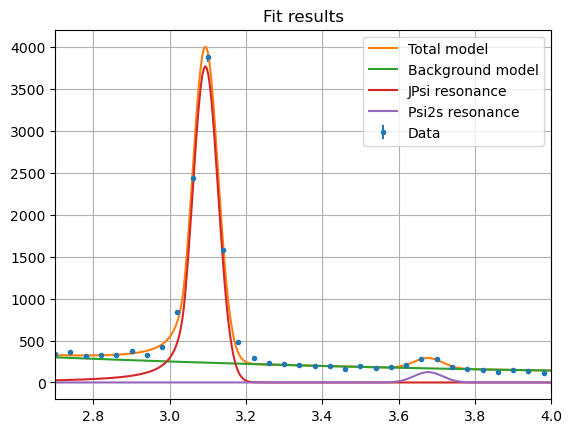

In [7]:
bin_number = 100
binned_data, bin_edges = np.histogram(data_HS, bins=bin_number)
err_binned_data = np.sqrt(binned_data)
bin_centers = (bin_edges[1:]+bin_edges[:-1])/2

x = np.linspace(2,6,1000)
graph_total_model = total_model.pdf(x)*total_model.get_yield()*(bin_edges[1]-bin_edges[0])
graph_bkg         = bkg_ext.pdf(x)    *bkg_ext.get_yield()    *(bin_edges[1]-bin_edges[0])
graph_JPsi        = cb_jpsi_ext.pdf(x)*cb_jpsi_ext.get_yield()*(bin_edges[1]-bin_edges[0])
graph_Psi2s       = cb_psi2s_ext.pdf(x)*cb_psi2s_ext.get_yield()*(bin_edges[1]-bin_edges[0])

plt.figure()
plt.errorbar(bin_centers, binned_data, yerr=err_binned_data, fmt='.', label='Data')
plt.plot(x,graph_total_model, label='Total model')
plt.plot(x,graph_bkg,   label='Background model')
plt.plot(x,graph_JPsi,  label='JPsi resonance')
plt.plot(x,graph_Psi2s, label='Psi2s resonance')
#mplhep.histplot(model_hist, label="model")
#mplhep.histplot(data_binned, label="data")
plt.legend()
plt.title("Fit results")
plt.xlim([2.7,4])
plt.grid()

## 2.5. Profile Likelihood

In [8]:
NLL_size = 100
xs_values = np.linspace(8,13,NLL_size)
NLL_values = np.zeros(NLL_size)

for i,xs in enumerate(xs_values):
    yield_psi2s = eps_uu * lumi * xs
    cb_psi2s_ext = cb_psi2s.create_extended(yield_psi2s)
    total_model = zfit.pdf.SumPDF([cb_jpsi_ext, cb_psi2s_ext, bkg_ext])

    loss = zfit.loss.ExtendedUnbinnedNLL(model = total_model,
                                         data = data)
    minimizer = zfit.minimize.Minuit()
    temp_result = minimizer.minimize(loss)
    NLL_values[i] = temp_result.fmin

In [9]:
min_NLL = result.fmin
NLL_variation = 2*(NLL_values-min_NLL)
xs_temporary = xs_values[NLL_variation<1]
xs_interval = [np.min(xs_temporary), np.max(xs_temporary)]
print(xs_interval)

[np.float64(9.16161616161616), np.float64(11.787878787878787)]


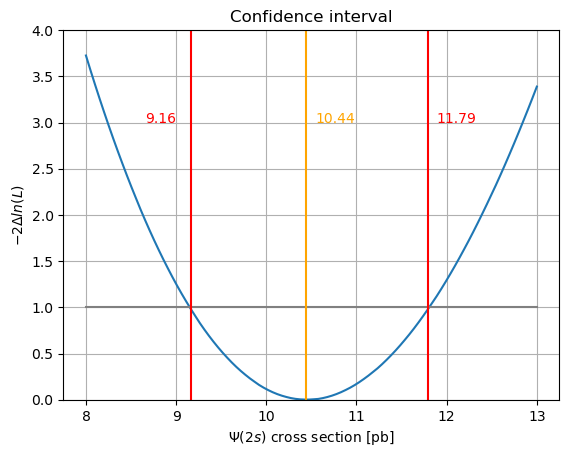

In [10]:
plt.plot(xs_values, NLL_variation, label='Profile Likelihood Ratio')
plt.plot(xs_values, np.ones(NLL_size), color='grey')
plt.axvline(xs_interval[0], color='r')
plt.axvline(xs_interval[1], color='r')
plt.axvline(result.values[1], color='orange')
plt.title('Confidence interval')
plt.xlabel('$\\Psi(2s)$ cross section [pb]')
plt.ylabel('$-2\\Delta ln(L)$')
plt.grid()
plt.ylim([0.,4.])
plt.text(xs_interval[0]-0.5,3, f'{xs_interval[0]:.2f}', color='r')
plt.text(xs_interval[1]+0.1,3, f'{xs_interval[1]:.2f}', color='r')
plt.text(result.values[1]+0.1,3, f'{result.values[1]:.2f}', color='orange')
plt.show()

## 3. Fit considering systematic uncertainty on the efficiency

In [58]:
#define the nominal k parameter and the uncertainty 
nominal_k = 1.0
eff_uncertainty = 0.1

#parameter where we apply the gaussian constraint
k = zfit.Parameter("k", 1, 0.5, 1.5)

#composite parameter that contains two degrees of freedom: k and xs
yield_psi2s = zfit.ComposedParameter("yield_psi2s", lambda xs, k: k * eps_uu * lumi * xs, params=[xs_psi2s, k])

#introduce the gaussian constraint
k_constraint = zfit.constraint.GaussianConstraint(params=k, observation=nominal_k, uncertainty=eff_uncertainty)

cb_psi2s = zfit.pdf.Gauss(obs=obs, mu=mu_psi2s, sigma=sigma_psi2s)
cb_psi2s_ext = cb_psi2s.create_extended(yield_psi2s)

#Total model
total_model = zfit.pdf.SumPDF([cb_jpsi_ext, cb_psi2s_ext, bkg_ext])

loss = zfit.loss.ExtendedUnbinnedNLL(   model = total_model,
                                        data = data,
                                        constraints = [k_constraint])
minimizer = zfit.minimize.Minuit()
result_sys = minimizer.minimize(loss)
result_sys.hesse()
print(result_sys)

FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_1043, Composed_autoparam_1044, Composed_autoparam_1045]] data=[<zfit.Data: Data obs=('mass',) shape=(28027, 1)>] constraints=[<zfit.core.constraint.GaussianConstraint object at 0x00000152FBB62610>]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 2.2e-05 │         23037.42 |  10008.52 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name           value  (rounded)        hesse    at limit
-----------  ------------------  -----------  ----------
yield_jpsi              8763.47  +/- 1.8e+02       False
xs_psi2s                 10.441  +/-     1.

In [30]:
NLL_values_sys = np.zeros(NLL_size)

for i, xs in enumerate(xs_values):
    yield_psi2s = zfit.ComposedParameter("yield_psi2s", lambda  k: k * eps_uu * lumi * xs, params=[k])
    cb_psi2s_ext = cb_psi2s.create_extended(yield_psi2s)
    total_model = zfit.pdf.SumPDF([cb_jpsi_ext, cb_psi2s_ext, bkg_ext])

    loss = zfit.loss.ExtendedUnbinnedNLL(   model = total_model,
                                            data = data,
                                            constraints = [k_constraint])
    minimizer = zfit.minimize.Minuit()
    temp_result = minimizer.minimize(loss)
    NLL_values_sys[i] = temp_result.fmin

In [33]:
min_NLL_sys = result_sys.fmin
NLL_variation_sys = 2*(NLL_values_sys-min_NLL_sys)
xs_temporary_sys = xs_values[NLL_variation_sys<1]
xs_interval_sys = [np.min(xs_temporary_sys), np.max(xs_temporary_sys)]
print(xs_interval_sys)

[np.float64(8.909090909090908), np.float64(12.242424242424242)]


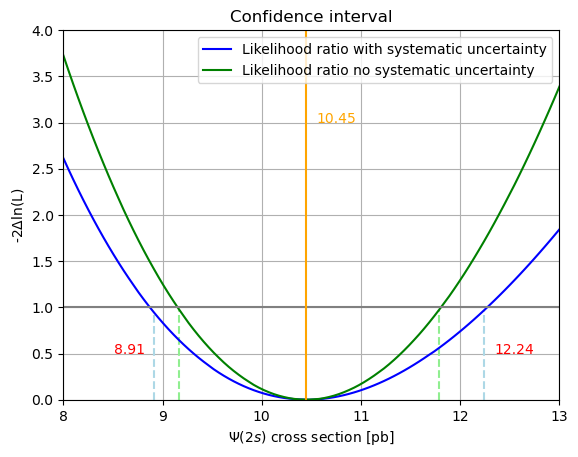

In [57]:

plt.plot([xs_interval_sys[0], xs_interval_sys[0]], [0, NLL_variation_sys[NLL_variation_sys<1][0]], color='lightblue', linestyle = "--")
plt.plot([xs_interval_sys[1], xs_interval_sys[1]], [0, NLL_variation_sys[NLL_variation_sys<1][-1]],color='lightblue', linestyle = "--")
plt.plot([xs_interval[0], xs_interval[0]], [0, NLL_variation[NLL_variation<1][0]], color='lightgreen', linestyle = "--")
plt.plot([xs_interval[1], xs_interval[1]], [0, NLL_variation[NLL_variation<1][-1]],color='lightgreen', linestyle = "--")

plt.plot(xs_values, NLL_variation_sys, color = "blue", label='Likelihood ratio with systematic uncertainty')
plt.plot(xs_values, NLL_variation, color = 'green', label='Likelihood ratio no systematic uncertainty')
plt.plot(xs_values, np.ones(NLL_size), color='grey')
plt.axvline(result_sys.values[1], color='orange', linestyle = "-")
plt.title('Confidence interval')
plt.xlabel('$\\Psi(2s)$ cross section [pb]')
plt.ylabel('-2$\\Delta$ln(L)')
plt.grid()
plt.ylim([0.,4.])
plt.xlim([8.,13.])
plt.text(xs_interval_sys[0]-0.4,0.5, f'{xs_interval_sys[0]:.2f}', color='r')
plt.text(xs_interval_sys[1]+0.1,0.5, f'{xs_interval_sys[1]:.2f}', color='r')
plt.text(result_sys.values[1]+0.1,3, f'{result_sys.values[1]:.2f}', color='orange')
plt.legend()
plt.show()